# **Objective**

The objective of this project is to perform data cleaning, feature engineering, and exploratory data analysis on the Superstore dataset to uncover sales trends, profit patterns, and business performance insights.
The goal is to identify high-performing categories, regions, and customer segments to support data-driven decision making.

# **Import Libraries**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline



# **Data Loading**

In [10]:
import pandas as pd
df=pd.read_csv('/content/Sample - Superstore.csv',encoding='latin1')
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


#**Data Understanding**

In this step, we explore the structure, shape,data types and statistical summary of the dataset.


In [18]:
df.shape

(9994, 21)

In [17]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# **Data Cleaning**

We cleaned the dataset by handling missing values, correcting data types, and removing duplicate records to ensure data quality.









In [22]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [25]:
df.ffill(inplace=True)

df.dropna(inplace=True)


In [27]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [37]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.head()


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,order_date,ship_date
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11-08,2016-11-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11-08,2016-11-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06-12,2016-06-16
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10-11,2015-10-18
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10-11,2015-10-18


In [48]:
df.drop(columns=df.columns[df.columns.duplicated(keep='first')])
df

,row_id,order_id,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,...,category,sub-category,product_name,sales,quantity,discount,profit,order_date,month,year
0,1,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11-08,11,2016
2,3,CA-2016-138688,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06-12,6,2016
3,4,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10-11,10,2015
5,6,CA-2014-115812,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,...,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694,2014-06-09,6,2014
12,13,CA-2017-114412,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,...,Office Supplies,Paper,Xerox 1967,15.5520,3,0.20,5.4432,2017-04-15,4,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9875,9876,CA-2015-130855,Standard Class,RF-19840,Roy Französisch,Consumer,United States,New York City,New York,10035,...,Office Supplies,Supplies,Acme Serrated Blade Letter Opener,6.3600,2,0.00,0.0636,2015-12-29,12,2015
9883,9884,CA-2014-112291,Standard Class,KE-16420,Katrina Edelman,Corporate,United States,Los Angeles,California,90008,...,Office Supplies,Envelopes,Staple envelope,11.1600,2,0.00,5.5800,2014-04-03,4,2014
9937,9938,CA-2016-164889,Second Class,CP-12340,Christine Phan,Corporate,United States,Los Angeles,California,90049,...,Furniture,Tables,Hon 61000 Series Interactive Training Tables,71.0880,2,0.20,-1.7772,2016-06-03,6,2016
9944,9945,CA-2015-145415,Second Class,RD-19660,Robert Dilbeck,Home Office,United States,Seattle,Washington,98103,...,Office Supplies,Storage,"Rogers Jumbo File, Granite",40.7400,3,0.00,0.4074,2015-04-12,4,2015


#**Feature Engineering**

In this part we were created new features such as shipping duration, order year/month, and profit margin to enhance analysis and uncover deeper business insights.

In [98]:
df['month'] = df['order_date'].dt.month
df['year'] = df['order_date'].dt.year

In [101]:
df['month'] = df['ship_date'].dt.month
df['year'] = df['ship_date'].dt.year

In [97]:
df['Shipping_Days'] = (df['ship_date'] - df['order_date']).dt.days


In [39]:
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,product_id,category,sub-category,product_name,sales,quantity,discount,profit,order_date,ship_date
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11-08,2016-11-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11-08,2016-11-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06-12,2016-06-16
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10-11,2015-10-18
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10-11,2015-10-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,US-2017-109484,2017-11-06,2017-11-12,Standard Class,RB-19705,Roger Barcio,Home Office,United States,Portland,...,OFF-BI-10004738,Office Supplies,Binders,Flexible Leather- Look Classic Collection Ring...,5.6820,1,0.70,-3.7880,2017-11-06,2017-11-12
96,97,CA-2017-161018,2017-11-09,2017-11-11,Second Class,PN-18775,Parhena Norris,Home Office,United States,New York City,...,FUR-FU-10000629,Furniture,Furnishings,9-3/4 Diameter Round Wall Clock,96.5300,7,0.00,40.5426,2017-11-09,2017-11-11
97,98,CA-2017-157833,2017-06-17,2017-06-20,First Class,KD-16345,Katherine Ducich,Consumer,United States,San Francisco,...,OFF-BI-10001721,Office Supplies,Binders,Trimflex Flexible Post Binders,51.3120,3,0.20,17.9592,2017-06-17,2017-06-20
98,99,CA-2016-149223,2016-09-06,2016-09-11,Standard Class,ER-13855,Elpida Rittenbach,Corporate,United States,Saint Paul,...,OFF-AP-10000358,Office Supplies,Appliances,Fellowes Basic Home/Office Series Surge Protec...,77.8800,6,0.00,22.5852,2016-09-06,2016-09-11


In [102]:
df['Profit_Margin']=(df['profit']/df['sales'])*100
df

,row_id,order_id,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,...,sales,quantity,discount,profit,order_date,month,year,ship_date,Shipping_Days,Profit_Margin
0,1,CA-2016-152156,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,...,261.9600,2,0.00,41.9136,2016-11-08,11,2016,2016-11-11,3,16.00
2,3,CA-2016-138688,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,...,14.6200,2,0.00,6.8714,2016-06-12,6,2016,2016-06-16,4,47.00
3,4,US-2015-108966,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,...,957.5775,5,0.45,-383.0310,2015-10-11,10,2015,2015-10-18,7,-40.00
5,6,CA-2014-115812,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,...,48.8600,7,0.00,14.1694,2014-06-09,6,2014,2014-06-14,5,29.00
12,13,CA-2017-114412,Standard Class,AA-10480,Andrew Allen,Consumer,United States,Concord,North Carolina,28027,...,15.5520,3,0.20,5.4432,2017-04-15,4,2017,2017-04-20,5,35.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9875,9876,CA-2015-130855,Standard Class,RF-19840,Roy Französisch,Consumer,United States,New York City,New York,10035,...,6.3600,2,0.00,0.0636,2015-12-29,1,2016,2016-01-05,7,1.00
9883,9884,CA-2014-112291,Standard Class,KE-16420,Katrina Edelman,Corporate,United States,Los Angeles,California,90008,...,11.1600,2,0.00,5.5800,2014-04-03,4,2014,2014-04-08,5,50.00
9937,9938,CA-2016-164889,Second Class,CP-12340,Christine Phan,Corporate,United States,Los Angeles,California,90049,...,71.0880,2,0.20,-1.7772,2016-06-03,6,2016,2016-06-06,3,-2.50
9944,9945,CA-2015-145415,Second Class,RD-19660,Robert Dilbeck,Home Office,United States,Seattle,Washington,98103,...,40.7400,3,0.00,0.4074,2015-04-12,4,2015,2015-04-17,5,1.00


#**Business Analysis**

In [60]:
Total_sales = df['sales'].sum()
print("Total sales = ",Total_sales)


Total sales =  273172.82110000006


In [61]:
Average_sales = df['sales'].mean()
print("Average Sales = ",Average_sales)

Average Sales =  220.83494025869044


In [64]:
Region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
Region_sales


,sales
region,
West,76268.4065
Central,74452.9356
East,64320.8450
South,58130.6340


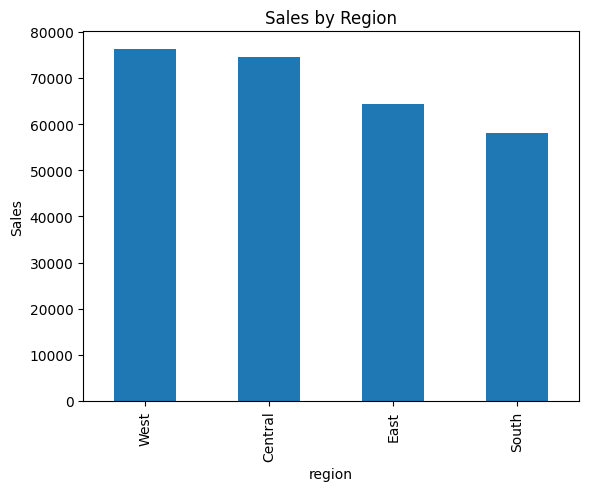

In [65]:
Region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()


In [70]:
Top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)
Top_products


,sales
product_name,
Canon imageCLASS 2200 Advanced Copier,11199.968
Cubify CubeX 3D Printer Triple Head Print,7999.980
Lexmark MX611dhe Monochrome Laser Printer,6119.964
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,5950.584
Samsung Galaxy Mega 6.3,4367.896
Hewlett Packard LaserJet 3310 Copier,4199.930
HON 5400 Series Task Chairs for Big and Tall,3504.900
Canon Imageclass D680 Copier / Fax,3359.952
Fellowes PB300 Plastic Comb Binding Machine,3103.920


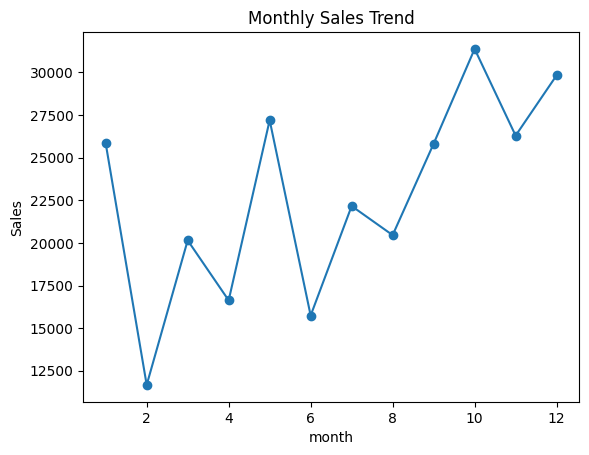

In [77]:
Monthly_sales =df.groupby('month')['sales'].sum()
Monthly_sales.plot(kind='line',marker='o')
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

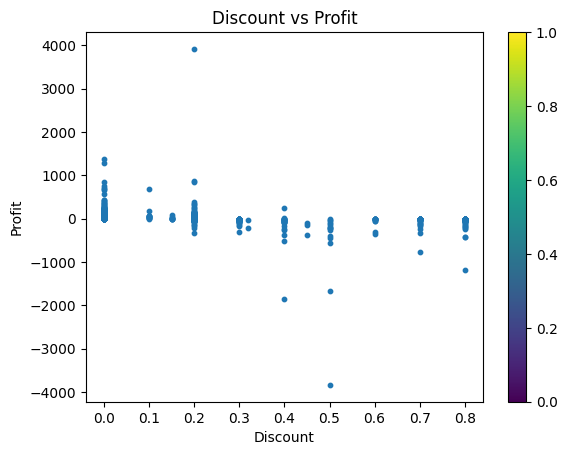

In [96]:
from backcall.backcall import sys
from matplotlib import colors
plt.scatter(df['discount'], df['profit'],s=10)
plt.colorbar()
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

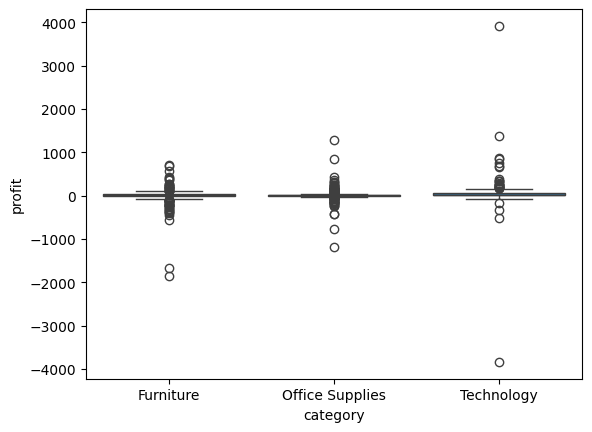

In [106]:
sns.boxplot(x='category', y='profit', data=df)
plt.show()


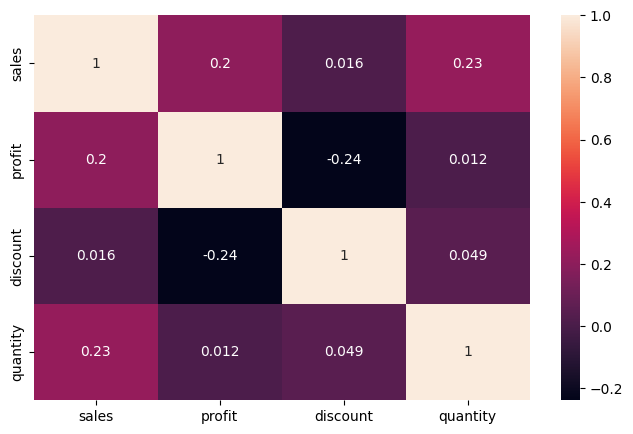

In [105]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['sales','profit','discount','quantity']].corr(), annot=True)
plt.show()


# **Business Insights**

📌 Insight 1:

Technology category generates the highest sales.

📌 Insight 2:

Sales peak observed in month 10.

📌 Insight 3:

West region generated highest sales.

📌 Insight 4:

Some regions generate high sales but low profit, indicating high discount impact.

📌 Insight 5:

Higher discounts are negatively correlated with profit.

📌 Insight 6:

Certain products result in consistent losses — need review.

📌 Insight 7:

Shipping duration varies across regions and may impact customer satisfaction.



# **Conclusion**

The analysis revealed that sales performance varies significantly across categories and regions. High discount strategies negatively impact profitability. Technology products are strong revenue drivers, while some sub-categories contribute to losses.
The company should optimize discount strategies and focus on high-margin segments to improve profitability.

In [108]:
df.to_csv('cleaned_sales_data.csv', index=False)

In [111]:
from google.colab import files
files.download("cleaned_sales_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>